In [1]:
# ============================================================
# Imports and notebook settings
#
# Purpose:
# Load libraries for time-series aggregation, forecasting,
# visualization, and error evaluation.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## Read AWS cost data

In [2]:
# ============================================================
# Read AWS CUR source file
#
# Purpose:
# Load AWS cost data and prepare it for daily time-series
# forecasting.
# ============================================================

aws_cur_path = "../synnepha_exercise_90d/synnepha_exercise_aws_cur_sample_90d.csv"

aws_cur_df = pd.read_csv(aws_cur_path)

aws_cur_df["date"] = pd.to_datetime(aws_cur_df["date"])

print("AWS CUR shape:", aws_cur_df.shape)
print("Date range:", aws_cur_df["date"].min(), "to", aws_cur_df["date"].max())

display(aws_cur_df.head())

AWS CUR shape: (8100, 8)
Date range: 2026-01-31 00:00:00 to 2026-04-30 00:00:00


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity
0,2026-01,2026-01-31,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,927.48,"4,780.38"
1,2026-01,2026-01-31,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,948.28,"4,985.43"
2,2026-01,2026-01-31,acct_001,AmazonS3,TimedStorage-ByteHrs,us-east-1,249.25,"10,695,835.07"
3,2026-01,2026-01-31,acct_001,AmazonS3,TimedStorage-ByteHrs,eu-west-1,287.45,"12,458,092.77"
4,2026-01,2026-01-31,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,592.14,"2,446.20"


## Create daily cost time series

In [3]:
# ============================================================
# Create daily cost time series
#
# Purpose:
# Aggregate AWS CUR rows into one total cost value per day.
#
# Forecast target:
# total_cost_usd
# ============================================================

daily_cost_df = (
    aws_cur_df
    .groupby("date", as_index=False)
    .agg(
        total_cost_usd=("cost_usd", "sum")
    )
    .sort_values("date")
)

# Create a continuous daily index.
# Missing dates are filled using forward fill as a simple operational assumption.
ts_df = (
    daily_cost_df
    .set_index("date")
    .asfreq("D")
)

ts_df["total_cost_usd"] = ts_df["total_cost_usd"].ffill()

display(ts_df.head())
display(ts_df.tail())

,total_cost_usd
date,
2026-01-31,"16,862.60"
2026-02-01,"17,107.44"
2026-02-02,"24,095.45"
2026-02-03,"23,620.45"
2026-02-04,"23,736.00"


,total_cost_usd
date,
2026-04-26,"17,512.82"
2026-04-27,"23,640.68"
2026-04-28,"26,272.61"
2026-04-29,"27,743.61"
2026-04-30,"27,440.17"


## Plot daily cost series

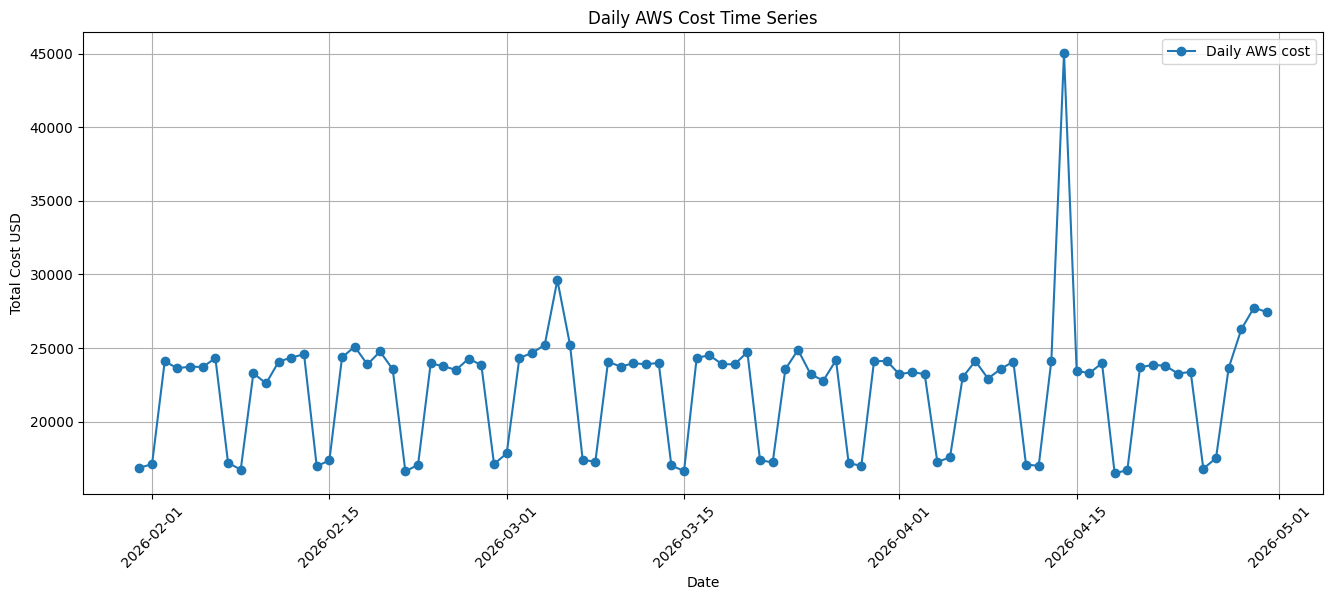

In [4]:
# ============================================================
# Visualize daily cost time series
#
# Purpose:
# Inspect the level, trend, seasonality, and possible spikes
# before fitting a forecasting model.
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    ts_df.index,
    ts_df["total_cost_usd"],
    marker="o",
    label="Daily AWS cost"
)

plt.title("Daily AWS Cost Time Series")
plt.xlabel("Date")
plt.ylabel("Total Cost USD")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Train/test split

In [5]:
# ============================================================
# Train/test split
#
# Purpose:
# Evaluate forecast quality on the most recent period.
#
# Design:
# - Train on earlier observations
# - Test on the last 14 days
#
# This simulates forecasting future daily cost from historical data.
# ============================================================

forecast_horizon = 14

train_series = ts_df["total_cost_usd"].iloc[:-forecast_horizon]
test_series = ts_df["total_cost_usd"].iloc[-forecast_horizon:]

print("Train period:", train_series.index.min(), "to", train_series.index.max())
print("Test period:", test_series.index.min(), "to", test_series.index.max())

print("Train size:", len(train_series))
print("Test size:", len(test_series))

Train period: 2026-01-31 00:00:00 to 2026-04-16 00:00:00
Test period: 2026-04-17 00:00:00 to 2026-04-30 00:00:00
Train size: 76
Test size: 14


In [7]:
train_series.head()

date
2026-01-31   16,862.60
2026-02-01   17,107.44
2026-02-02   24,095.45
2026-02-03   23,620.45
2026-02-04   23,736.00
Freq: D, Name: total_cost_usd, dtype: float64

## Fit Holt-Winters model

In [8]:
# ============================================================
# Fit Holt-Winters Exponential Smoothing model
#
# Purpose:
# Build a simple and explainable forecast model.
#
# Model selection rationale:
# - The dataset is short, around 90 days
# - The target is a daily time series
# - Weekly seasonality is plausible in cloud workloads
# - Holt-Winters can capture level, trend, and seasonality
# - It is lightweight and suitable for daily production retraining
# ============================================================

hw_model = ExponentialSmoothing(
    train_series,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

hw_fit = hw_model.fit(optimized=True)

test_forecast = hw_fit.forecast(forecast_horizon)

forecast_eval_df = pd.DataFrame({
    "date": test_series.index,
    "actual_total_cost_usd": test_series.values,
    "forecast_total_cost_usd": test_forecast.values
})

forecast_eval_df["forecast_error"] = (
    forecast_eval_df["actual_total_cost_usd"] -
    forecast_eval_df["forecast_total_cost_usd"]
)

forecast_eval_df["absolute_error"] = forecast_eval_df["forecast_error"].abs()

display(forecast_eval_df)

,date,actual_total_cost_usd,forecast_total_cost_usd,forecast_error,absolute_error
0,2026-04-17,"23,967.83","24,592.40",-624.57,624.57
1,2026-04-18,"16,489.80","17,631.15","-1,141.35","1,141.35"
2,2026-04-19,"16,697.57","17,687.54",-989.97,989.97
3,2026-04-20,"23,677.27","24,366.92",-689.65,689.65
4,2026-04-21,"23,855.07","28,391.48","-4,536.41","4,536.41"
5,2026-04-22,"23,792.98","24,096.02",-303.04,303.04
6,2026-04-23,"23,259.84","24,746.11","-1,486.27","1,486.27"
7,2026-04-24,"23,377.25","24,696.95","-1,319.70","1,319.70"
8,2026-04-25,"16,800.20","17,735.70",-935.50,935.50
9,2026-04-26,"17,512.82","17,792.09",-279.27,279.27


## Forecast evaluation

In [9]:
# ============================================================
# Forecast evaluation
#
# Purpose:
# Quantify model performance on the holdout period.
#
# Metrics:
# - MAE: average absolute forecast error
# - RMSE: penalizes larger errors
# - MAPE: percentage error, easier for business interpretation
# ============================================================

mae = mean_absolute_error(
    forecast_eval_df["actual_total_cost_usd"],
    forecast_eval_df["forecast_total_cost_usd"]
)

rmse = np.sqrt(
    mean_squared_error(
        forecast_eval_df["actual_total_cost_usd"],
        forecast_eval_df["forecast_total_cost_usd"]
    )
)

mape = (
    np.mean(
        np.abs(
            forecast_eval_df["forecast_error"] /
            forecast_eval_df["actual_total_cost_usd"]
        )
    )
    * 100
)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:,.2f}%")

MAE:  1,535.18
RMSE: 1,956.96
MAPE: 6.57%


## Plot test forecast

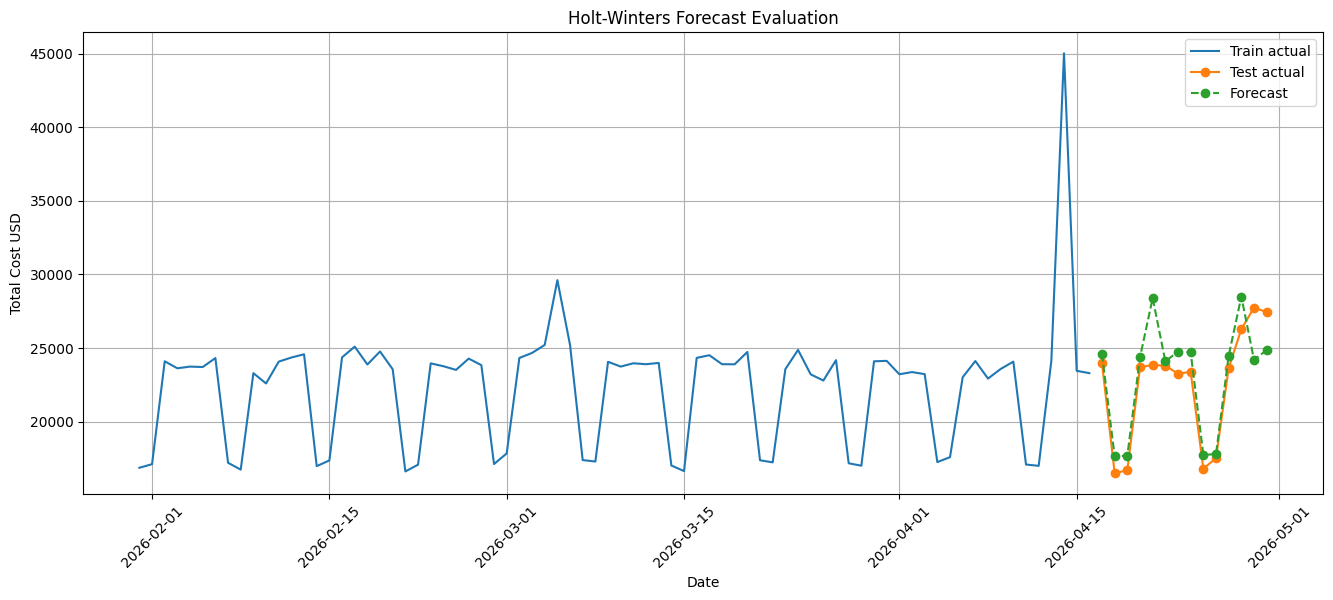

In [10]:
# ============================================================
# Visualize forecast evaluation
#
# Purpose:
# Compare actual and forecasted costs on the holdout period.
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    train_series.index,
    train_series.values,
    label="Train actual"
)

plt.plot(
    test_series.index,
    test_series.values,
    marker="o",
    label="Test actual"
)

plt.plot(
    forecast_eval_df["date"],
    forecast_eval_df["forecast_total_cost_usd"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Holt-Winters Forecast Evaluation")
plt.xlabel("Date")
plt.ylabel("Total Cost USD")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Refit model on full data

In [11]:
# ============================================================
# Refit model on full daily cost history
#
# Purpose:
# After evaluation, train the final model on all available data
# and generate the future forecast.
# ============================================================

final_hw_model = ExponentialSmoothing(
    ts_df["total_cost_usd"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

final_hw_fit = final_hw_model.fit(optimized=True)

future_horizon = 14

future_forecast = final_hw_fit.forecast(future_horizon)

future_forecast_df = pd.DataFrame({
    "date": future_forecast.index,
    "forecast_total_cost_usd": future_forecast.values
})

display(future_forecast_df)

,date,forecast_total_cost_usd
0,2026-05-01,"24,660.21"
1,2026-05-02,"17,621.06"
2,2026-05-03,"17,752.70"
3,2026-05-04,"24,493.99"
4,2026-05-05,"26,458.18"
5,2026-05-06,"24,647.10"
6,2026-05-07,"25,091.28"
7,2026-05-08,"24,749.55"
8,2026-05-09,"17,710.40"
9,2026-05-10,"17,842.04"


## Add simple forecast bands

In [13]:
# ============================================================
# Add simple forecast uncertainty bands
#
# Purpose:
# Create an operational forecast range using historical residuals
# from the holdout period.
#
# Note:
# This is a simple approximation, not a formal probabilistic
# confidence interval.
# ============================================================

residual_std = forecast_eval_df["forecast_error"].std()

future_forecast_df["lower_band"] = (
    future_forecast_df["forecast_total_cost_usd"] -
    1.96 * residual_std
)

future_forecast_df["upper_band"] = (
    future_forecast_df["forecast_total_cost_usd"] +
    1.96 * residual_std
)

display(future_forecast_df)

,date,forecast_total_cost_usd,lower_band,upper_band
0,2026-05-01,"24,660.21","20,912.33","28,408.09"
1,2026-05-02,"17,621.06","13,873.18","21,368.94"
2,2026-05-03,"17,752.70","14,004.82","21,500.58"
3,2026-05-04,"24,493.99","20,746.11","28,241.87"
4,2026-05-05,"26,458.18","22,710.30","30,206.06"
5,2026-05-06,"24,647.10","20,899.22","28,394.98"
6,2026-05-07,"25,091.28","21,343.40","28,839.16"
7,2026-05-08,"24,749.55","21,001.67","28,497.43"
8,2026-05-09,"17,710.40","13,962.52","21,458.28"
9,2026-05-10,"17,842.04","14,094.16","21,589.92"


## Plot final future forecast

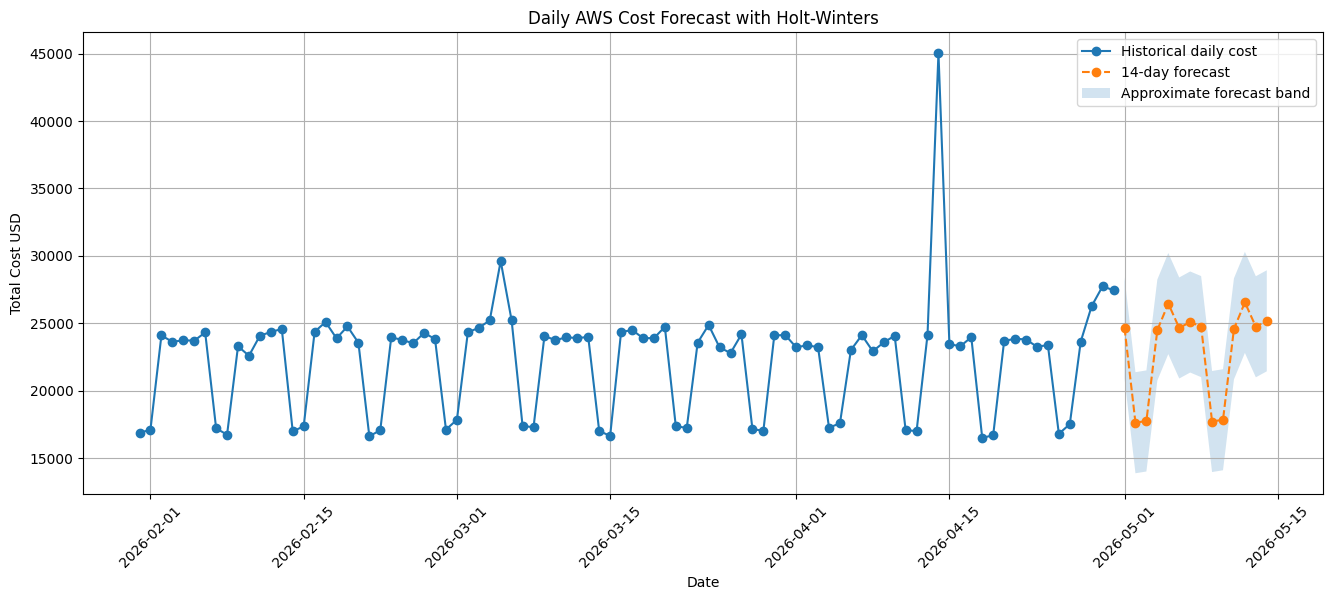

In [14]:
# ============================================================
# Visualize final future forecast
#
# Purpose:
# Show historical daily cost and 14-day forecast with simple
# uncertainty bands.
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    ts_df.index,
    ts_df["total_cost_usd"],
    marker="o",
    label="Historical daily cost"
)

plt.plot(
    future_forecast_df["date"],
    future_forecast_df["forecast_total_cost_usd"],
    marker="o",
    linestyle="--",
    label="14-day forecast"
)

plt.fill_between(
    future_forecast_df["date"],
    future_forecast_df["lower_band"],
    future_forecast_df["upper_band"],
    alpha=0.20,
    label="Approximate forecast band"
)

plt.title("Daily AWS Cost Forecast with Holt-Winters")
plt.xlabel("Date")
plt.ylabel("Total Cost USD")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Create final forecast report

In [15]:
# ============================================================
# Create final forecast report
#
# Purpose:
# Create one clean CSV output for Question 2.
#
# Output includes:
# - forecast date
# - forecasted daily cost
# - lower and upper forecast bands
# - model name
# - model selection rationale
# - evaluation metrics
# ============================================================

forecast_output_df = future_forecast_df.copy()

forecast_output_df["model"] = "Holt-Winters Exponential Smoothing"
forecast_output_df["seasonality"] = "Weekly seasonality, seasonal_periods=7"
forecast_output_df["mae_holdout"] = mae
forecast_output_df["rmse_holdout"] = rmse
forecast_output_df["mape_holdout_pct"] = mape
forecast_output_df["model_selection_rationale"] = (
    "Selected because the dataset is short, daily, and suitable for a simple, "
    "explainable model that captures level, trend, and weekly seasonality."
)

display(forecast_output_df)

,date,forecast_total_cost_usd,lower_band,upper_band,model,seasonality,mae_holdout,rmse_holdout,mape_holdout_pct,model_selection_rationale
0,2026-05-01,"24,660.21","20,912.33","28,408.09",Holt-Winters Exponential Smoothing,"Weekly seasonality, seasonal_periods=7","1,535.18","1,956.96",6.57,"Selected because the dataset is short, daily, ..."
1,2026-05-02,"17,621.06","13,873.18","21,368.94",Holt-Winters Exponential Smoothing,"Weekly seasonality, seasonal_periods=7","1,535.18","1,956.96",6.57,"Selected because the dataset is short, daily, ..."
2,2026-05-03,"17,752.70","14,004.82","21,500.58",Holt-Winters Exponential Smoothing,"Weekly seasonality, seasonal_periods=7","1,535.18","1,956.96",6.57,"Selected because the dataset is short, daily, ..."
3,2026-05-04,"24,493.99","20,746.11","28,241.87",Holt-Winters Exponential Smoothing,"Weekly seasonality, seasonal_periods=7","1,535.18","1,956.96",6.57,"Selected because the dataset is short, daily, ..."
4,2026-05-05,"26,458.18","22,710.30","30,206.06",Holt-Winters Exponential Smoothing,"Weekly seasonality, seasonal_periods=7","1,535.18","1,956.96",6.57,"Selected because the dataset is short, daily, ..."
5,2026-05-06,"24,647.10","20,899.22","28,394.98",Holt-Winters Exponential Smoothing,"Weekly seasonality, seasonal_periods=7","1,535.18","1,956.96",6.57,"Selected because the dataset is short, daily, ..."
6,2026-05-07,"25,091.28","21,343.40","28,839.16",Holt-Winters Exponential Smoothing,"Weekly seasonality, seasonal_periods=7","1,535.18","1,956.96",6.57,"Selected because the dataset is short, daily, ..."
7,2026-05-08,"24,749.55","21,001.67","28,497.43",Holt-Winters Exponential Smoothing,"Weekly seasonality, seasonal_periods=7","1,535.18","1,956.96",6.57,"Selected because the dataset is short, daily, ..."
8,2026-05-09,"17,710.40","13,962.52","21,458.28",Holt-Winters Exponential Smoothing,"Weekly seasonality, seasonal_periods=7","1,535.18","1,956.96",6.57,"Selected because the dataset is short, daily, ..."
9,2026-05-10,"17,842.04","14,094.16","21,589.92",Holt-Winters Exponential Smoothing,"Weekly seasonality, seasonal_periods=7","1,535.18","1,956.96",6.57,"Selected because the dataset is short, daily, ..."


## Save one CSV for Question 2

In [16]:
# ============================================================
# Save final forecasting output
#
# Purpose:
# Create exactly one CSV file for Question 2.
# ============================================================

forecast_output_df.to_csv(
    "../synnepha_exercise_90d/results/question_2_daily_cost_forecast.csv",
    index=False
)

print("Saved: question_2_daily_cost_forecast.csv")

Saved: question_2_daily_cost_forecast.csv
